# Predictive Likelihood Comparison

This notebook compares the out-of-sample predictive performance of the Normal SABR and memory-augmented Rough-SABR particle filters.

The comparison is based on paired model runs that use the same random seeds and timestamps. The analysis considers:

- one-step-ahead predictive log-likelihood;
- cumulative predictive log-likelihood; and
- the corresponding Rough-SABR-minus-Normal-SABR differences.

Results are presented separately for each seed and as averages across seeds.

## Predictive likelihood measures

For model $M$, timestamp $t$, and random seed $s$, the one-step-ahead predictive log-likelihood is

$$
\ell^{M}_{t,s}
=
\log p_M\left(Y_t \mid Y_{1:t-1}\right).
$$

The one-step-ahead difference is defined as

$$
\Delta_{t,s}
=
\ell^{\mathrm{Rough}}_{t,s}
-
\ell^{\mathrm{Normal}}_{t,s}.
$$

Therefore, $\Delta_{t,s}>0$ favours Rough-SABR, while $\Delta_{t,s}<0$ favours Normal SABR.

The cumulative predictive log-likelihood is

$$
C^{M}_{t,s}
=
\sum_{u \leq t}\ell^{M}_{u,s},
$$

and the cumulative difference is

$$
D_{t,s}
=
C^{\mathrm{Rough}}_{t,s}
-
C^{\mathrm{Normal}}_{t,s}.
$$

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

## Configuration

This notebook assumes that it is stored in `notebooks/` and that model outputs are stored in `outputs/`. The folder patterns below identify the paired Normal SABR and Rough-SABR experiments included in the comparison.

In [2]:
REPOSITORY_ROOT = Path("..").resolve()
OUTPUTS_DIR = REPOSITORY_ROOT / "outputs"

NORMAL_RUN_PATTERN = "normal_sabr_400ts_no_A_RW_seed*"
ROUGH_RUN_PATTERN = "rough_sabr_400ts_logU0_seed*"

MAX_TIMESTAMPS = 400

FIGURE_DIR = (
    REPOSITORY_ROOT
    / "outputs"
    / "comparisons"
    / "predictive_likelihood"
    / "figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Load and align paired runs

In [3]:
def extract_seed(folder: Path) -> int:
    match = re.search(r"seed(\d+)", folder.name)

    if match is None:
        raise ValueError(f"Seed not found in folder name: {folder.name}")

    return int(match.group(1))


def load_predictive_likelihood(csv_path: Path, column_name: str) -> pd.DataFrame:
    data = pd.read_csv(csv_path)

    possible_columns = [
        "predictive_log_likelihood",
        "predictive_loglikelihood",
        "predictive_loglik",
        "predictive_log_lik",
        "log_predictive_likelihood",
    ]

    likelihood_column = next(
        (column for column in possible_columns if column in data.columns),
        None,
    )

    if likelihood_column is None:
        raise ValueError(
            f"Predictive log-likelihood column not found in {csv_path}"
        )

    return (
        data[["t_index", likelihood_column]]
        .rename(columns={likelihood_column: column_name})
        .dropna()
        .sort_values("t_index")
        .drop_duplicates("t_index")
        .reset_index(drop=True)
    )

In [4]:
normal_runs = {
    extract_seed(folder): folder
    for folder in OUTPUTS_DIR.glob(NORMAL_RUN_PATTERN)
    if folder.is_dir()
}

rough_runs = {
    extract_seed(folder): folder
    for folder in OUTPUTS_DIR.glob(ROUGH_RUN_PATTERN)
    if folder.is_dir()
}

seeds = sorted(set(normal_runs) & set(rough_runs))

if not seeds:
    raise ValueError(
        "No paired Normal SABR and Rough-SABR runs were found."
    )

print("Paired seeds:", seeds)

Paired seeds: [123, 456, 789, 101112, 131415]


In [5]:
paired_runs = []

for seed in seeds:
    normal = load_predictive_likelihood(
        normal_runs[seed] / "loglikelihood.csv",
        "normal_predictive_ll",
    )

    rough = load_predictive_likelihood(
        rough_runs[seed] / "loglikelihood.csv",
        "rough_predictive_ll",
    )

    paired_seed = normal.merge(
        rough,
        on="t_index",
        how="inner",
        validate="one_to_one",
    )

    paired_seed["seed"] = seed
    paired_runs.append(paired_seed)

paired = pd.concat(paired_runs, ignore_index=True)

common_timestamps = sorted(
    set.intersection(
        *[
            set(frame["t_index"])
            for frame in paired_runs
        ]
    )
)

if MAX_TIMESTAMPS is not None:
    common_timestamps = common_timestamps[:MAX_TIMESTAMPS]

paired = (
    paired[paired["t_index"].isin(common_timestamps)]
    .sort_values(["seed", "t_index"])
    .reset_index(drop=True)
)

observations_per_seed = paired.groupby("seed")["t_index"].nunique()

if observations_per_seed.nunique() != 1:
    raise ValueError("The paired runs do not contain the same timestamps.")

print(
    f"Comparison uses {len(seeds)} seeds and "
    f"{observations_per_seed.iloc[0]} timestamps per seed."
)

Comparison uses 5 seeds and 400 timestamps per seed.


## Construct comparison measures

In [6]:
paired["one_step_difference"] = (
    paired["rough_predictive_ll"]
    - paired["normal_predictive_ll"]
)

paired["normal_cumulative_ll"] = (
    paired.groupby("seed")["normal_predictive_ll"].cumsum()
)

paired["rough_cumulative_ll"] = (
    paired.groupby("seed")["rough_predictive_ll"].cumsum()
)

paired["cumulative_difference"] = (
    paired["rough_cumulative_ll"]
    - paired["normal_cumulative_ll"]
)

paired.head()

,t_index,normal_predictive_ll,rough_predictive_ll,seed,one_step_difference,normal_cumulative_ll,rough_cumulative_ll,cumulative_difference
0,0,-29.0769,-30.7423,123,-1.6654,-29.0769,-30.7423,-1.6654
1,1,-27.0855,-21.4266,123,5.6589,-56.1623,-52.1689,3.9934
2,2,-28.0907,-22.7136,123,5.3771,-84.2530,-74.8825,9.3705
3,3,-20.5486,-13.2945,123,7.2541,-104.8016,-88.1770,16.6246
4,4,-23.8186,-19.9318,123,3.8868,-128.6202,-108.1087,20.5114


## Seed-level summary

In [7]:
seed_summary = (
    paired.groupby("seed", as_index=False)
    .agg(
        timestamps=("t_index", "nunique"),
        mean_one_step_difference=("one_step_difference", "mean"),
        median_one_step_difference=("one_step_difference", "median"),
        final_normal_cumulative_ll=("normal_cumulative_ll", "last"),
        final_rough_cumulative_ll=("rough_cumulative_ll", "last"),
        final_cumulative_difference=("cumulative_difference", "last"),
    )
)

seed_summary["preferred_model"] = np.where(
    seed_summary["final_cumulative_difference"] > 0,
    "Rough-SABR",
    "Normal SABR",
)

display(seed_summary)

,seed,timestamps,mean_one_step_difference,median_one_step_difference,final_normal_cumulative_ll,final_rough_cumulative_ll,final_cumulative_difference,preferred_model
0,123,400,0.8700,0.8059,"-7,426.7547","-7,078.7511",348.0035,Rough-SABR
1,456,400,0.9276,0.6590,"-7,518.2249","-7,147.1726",371.0523,Rough-SABR
2,789,400,0.5942,0.6178,"-7,456.3071","-7,218.6416",237.6656,Rough-SABR
3,101112,400,3.4036,1.7627,"-8,484.8708","-7,123.4270","1,361.4439",Rough-SABR
4,131415,400,7.4455,6.4689,"-10,228.1398","-7,249.9371","2,978.2027",Rough-SABR


In [8]:
across_seeds = (
    paired.groupby("t_index", as_index=False)
    .agg(
        normal_one_step_mean=("normal_predictive_ll", "mean"),
        normal_one_step_std=("normal_predictive_ll", "std"),
        rough_one_step_mean=("rough_predictive_ll", "mean"),
        rough_one_step_std=("rough_predictive_ll", "std"),
        normal_cumulative_mean=("normal_cumulative_ll", "mean"),
        normal_cumulative_std=("normal_cumulative_ll", "std"),
        rough_cumulative_mean=("rough_cumulative_ll", "mean"),
        rough_cumulative_std=("rough_cumulative_ll", "std"),
        one_step_difference_mean=("one_step_difference", "mean"),
        one_step_difference_std=("one_step_difference", "std"),
        cumulative_difference_mean=("cumulative_difference", "mean"),
        cumulative_difference_std=("cumulative_difference", "std"),
    )
)

## 1. One-step-ahead predictive log-likelihood by seed

Each figure compares the paired Normal SABR and Rough-SABR runs for one random seed.

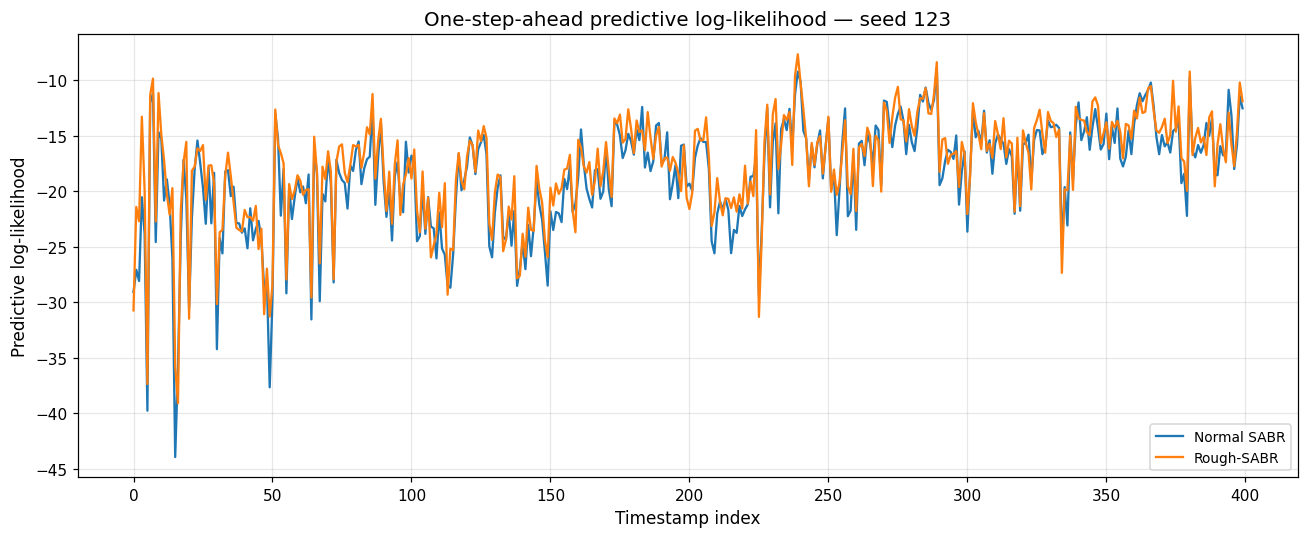

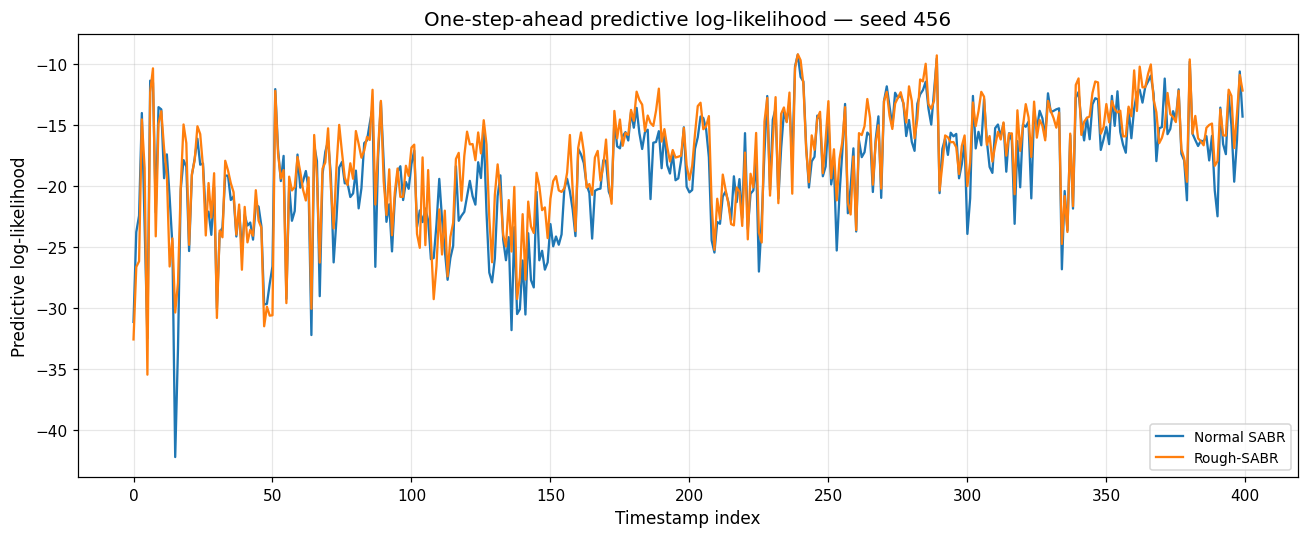

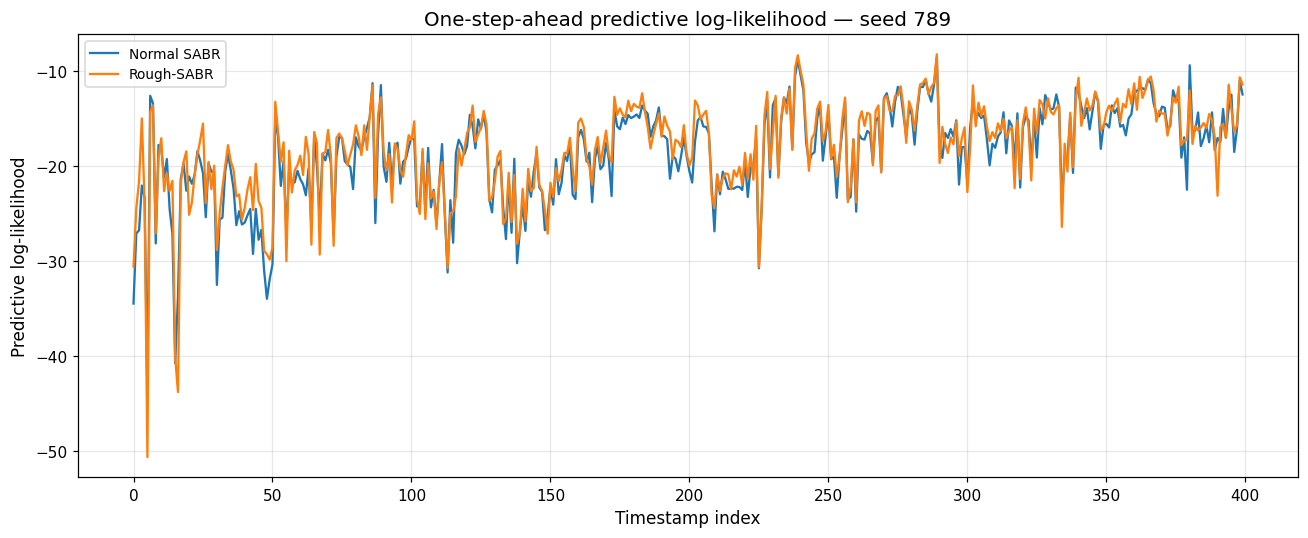

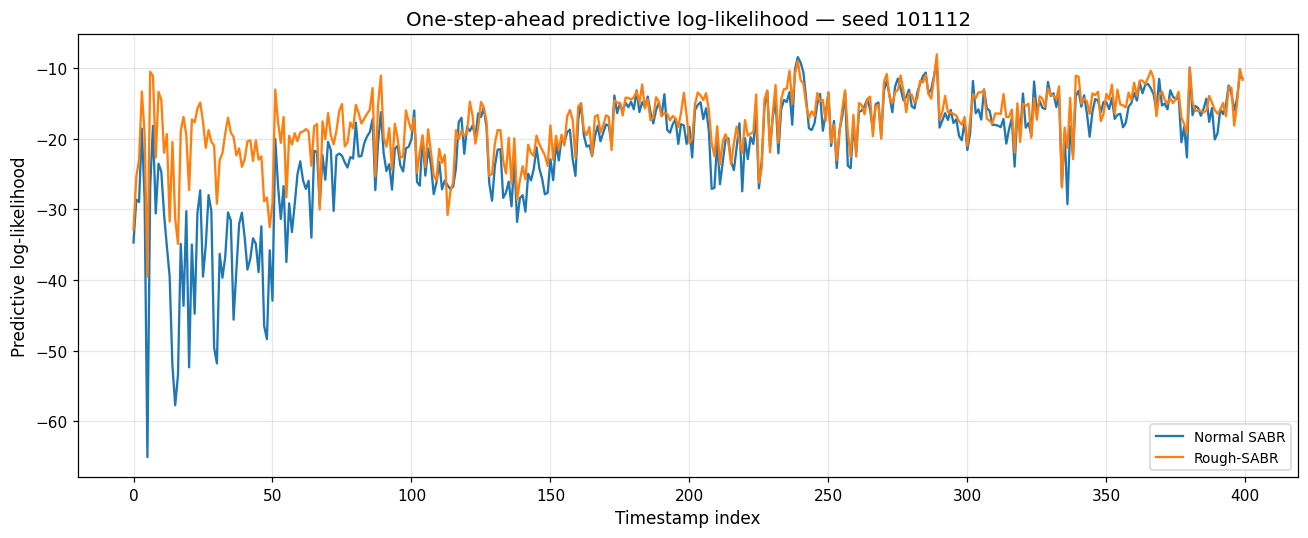

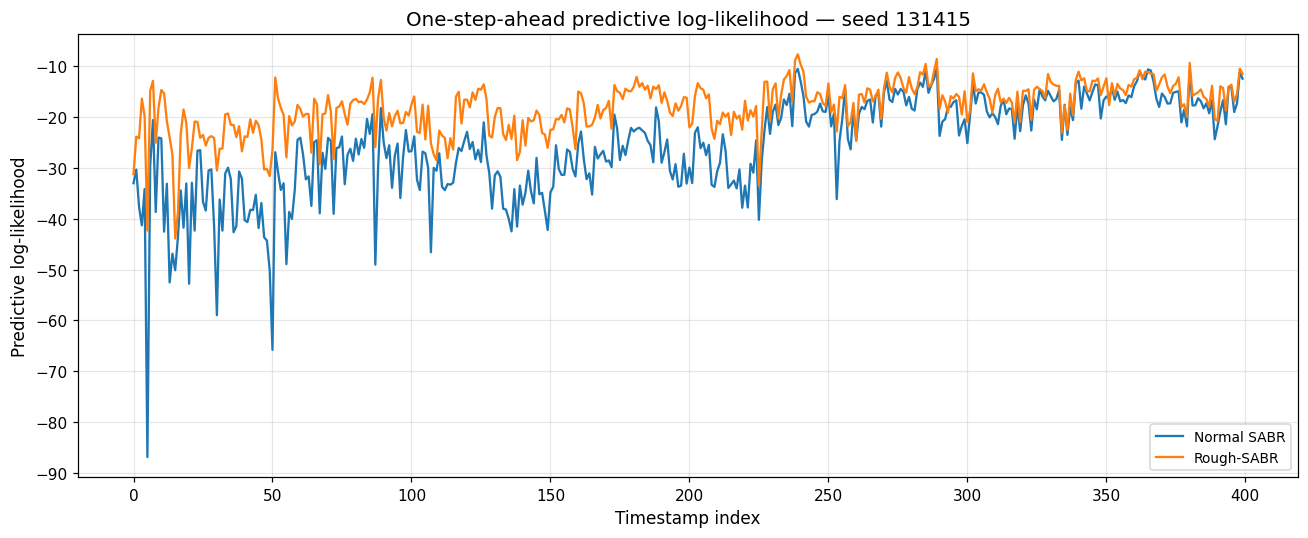

In [9]:
for seed, seed_data in paired.groupby("seed"):
    fig, ax = plt.subplots()

    ax.plot(
        seed_data["t_index"],
        seed_data["normal_predictive_ll"],
        label="Normal SABR",
    )
    ax.plot(
        seed_data["t_index"],
        seed_data["rough_predictive_ll"],
        label="Rough-SABR",
    )

    ax.set_title(
        f"One-step-ahead predictive log-likelihood — seed {seed}"
    )
    ax.set_xlabel("Timestamp index")
    ax.set_ylabel("Predictive log-likelihood")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"one_step_predictive_ll_seed_{seed}.png",
        bbox_inches="tight",
    )
    plt.show()

## 2. One-step-ahead predictive log-likelihood across seeds

The solid lines show the mean across seeds. The shaded regions show one standard deviation across seeds.

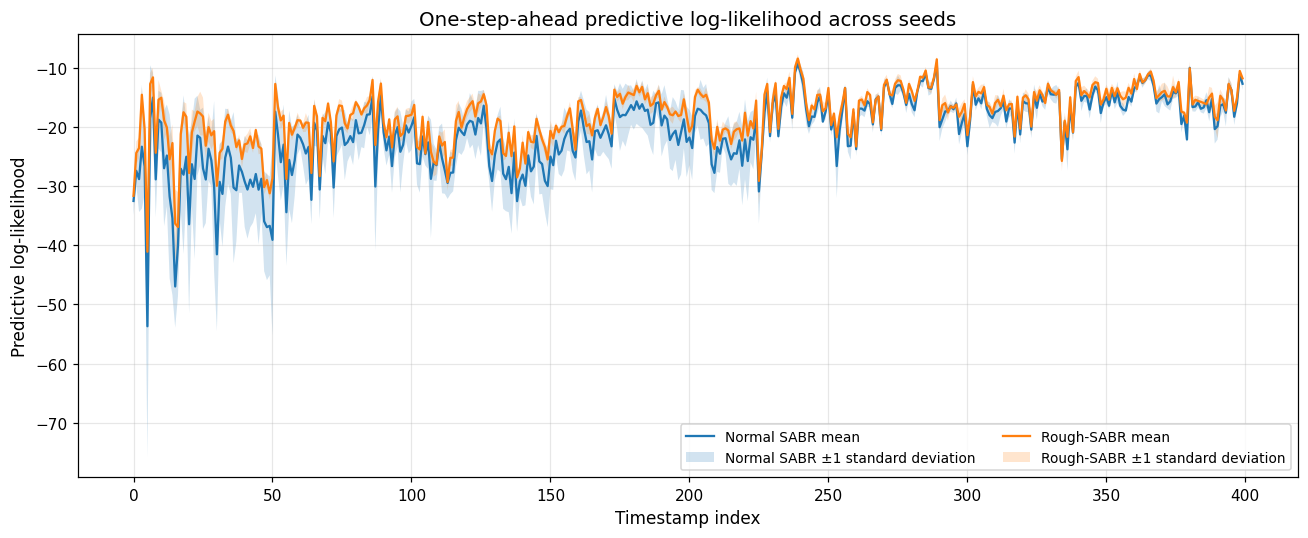

In [10]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["normal_one_step_mean"],
    label="Normal SABR mean",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["normal_one_step_mean"]
    - across_seeds["normal_one_step_std"],
    across_seeds["normal_one_step_mean"]
    + across_seeds["normal_one_step_std"],
    alpha=0.2,
    label="Normal SABR ±1 standard deviation",
)

ax.plot(
    across_seeds["t_index"],
    across_seeds["rough_one_step_mean"],
    label="Rough-SABR mean",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["rough_one_step_mean"]
    - across_seeds["rough_one_step_std"],
    across_seeds["rough_one_step_mean"]
    + across_seeds["rough_one_step_std"],
    alpha=0.2,
    label="Rough-SABR ±1 standard deviation",
)

ax.set_title("One-step-ahead predictive log-likelihood across seeds")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Predictive log-likelihood")
ax.grid(alpha=0.3)
ax.legend(ncol=2)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "one_step_predictive_ll_across_seeds.png",
    bbox_inches="tight",
)
plt.show()

## 3. Normal SABR one-step-ahead predictive log-likelihood by seed

This figure isolates the variation in the Normal SABR predictive
log-likelihood across repeated runs. Differences between paths arise
from the stochastic elements of the particle filter and nested
Monte Carlo pricing.

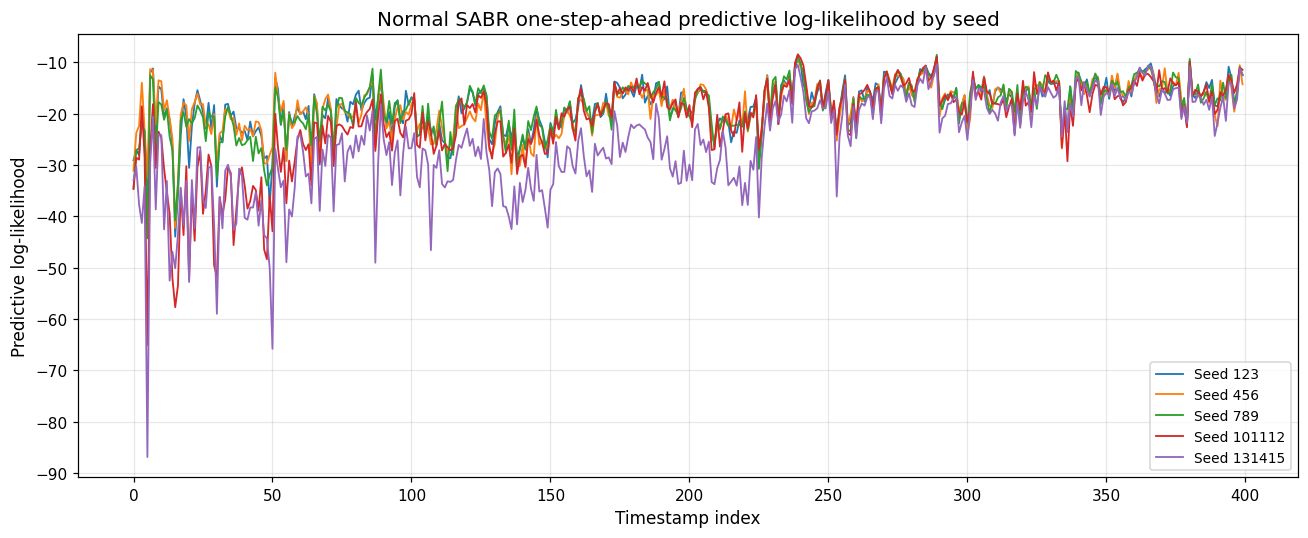

In [11]:
fig, ax = plt.subplots()

for seed, seed_data in paired.groupby("seed"):
    ax.plot(
        seed_data["t_index"],
        seed_data["normal_predictive_ll"],
        linewidth=1.2,
        label=f"Seed {seed}",
    )

ax.set_title(
    "Normal SABR one-step-ahead predictive log-likelihood by seed"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Predictive log-likelihood")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "normal_predictive_ll_by_seed.png",
    bbox_inches="tight",
)
plt.show()

## 4. Rough-SABR one-step-ahead predictive log-likelihood by seed

This figure provides the corresponding seed-level comparison for
the memory-augmented Rough-SABR filter.

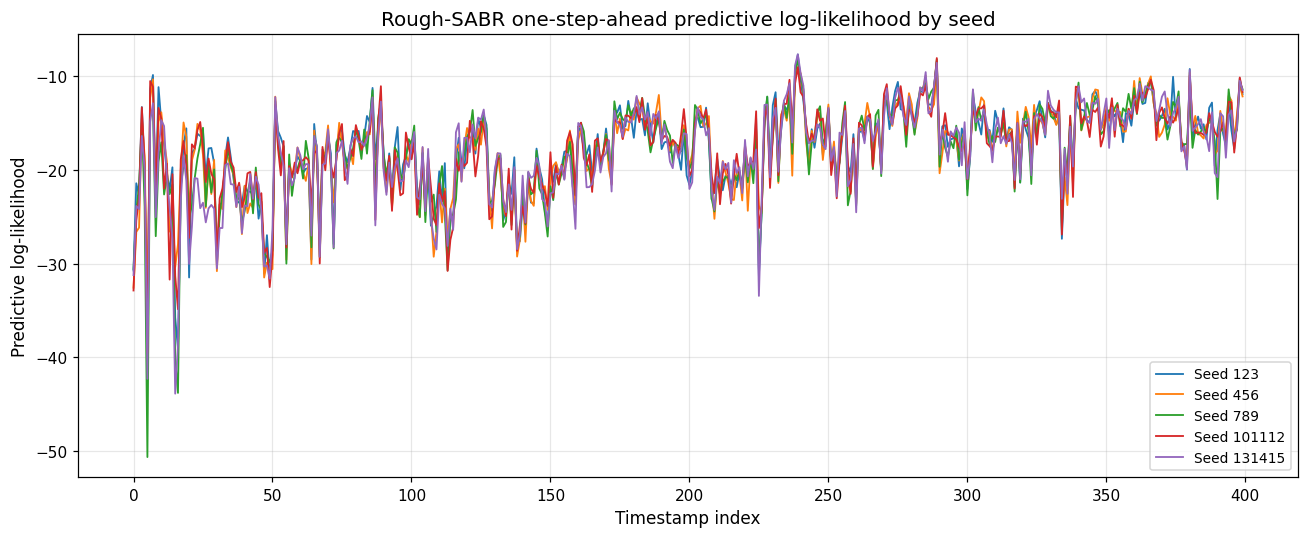

In [12]:
fig, ax = plt.subplots()

for seed, seed_data in paired.groupby("seed"):
    ax.plot(
        seed_data["t_index"],
        seed_data["rough_predictive_ll"],
        linewidth=1.2,
        label=f"Seed {seed}",
    )

ax.set_title(
    "Rough-SABR one-step-ahead predictive log-likelihood by seed"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Predictive log-likelihood")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "rough_predictive_ll_by_seed.png",
    bbox_inches="tight",
)
plt.show()

## 5. Across-seed standard deviation of predictive log-likelihood

The across-seed standard deviation measures the sensitivity of each
model's one-step-ahead predictive log-likelihood to the random seed
at each timestamp. Larger values indicate greater stochastic
instability across repeated runs.

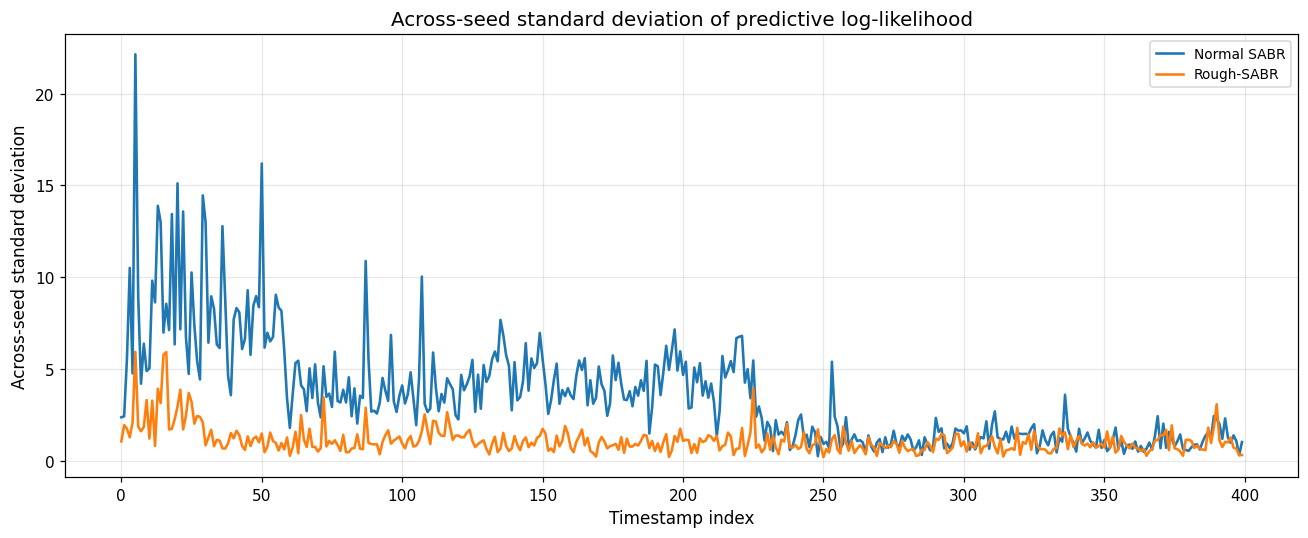

In [13]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["normal_one_step_std"],
    linewidth=1.7,
    label="Normal SABR",
)

ax.plot(
    across_seeds["t_index"],
    across_seeds["rough_one_step_std"],
    linewidth=1.7,
    label="Rough-SABR",
)

ax.set_title(
    "Across-seed standard deviation of predictive log-likelihood"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Across-seed standard deviation")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "predictive_ll_standard_deviation_by_model.png",
    bbox_inches="tight",
)
plt.show()

## 6. Smoothed across-seed predictive instability

A rolling mean is applied to the across-seed standard deviation to
identify persistent differences in model stability that may be
obscured by timestamp-level fluctuations.

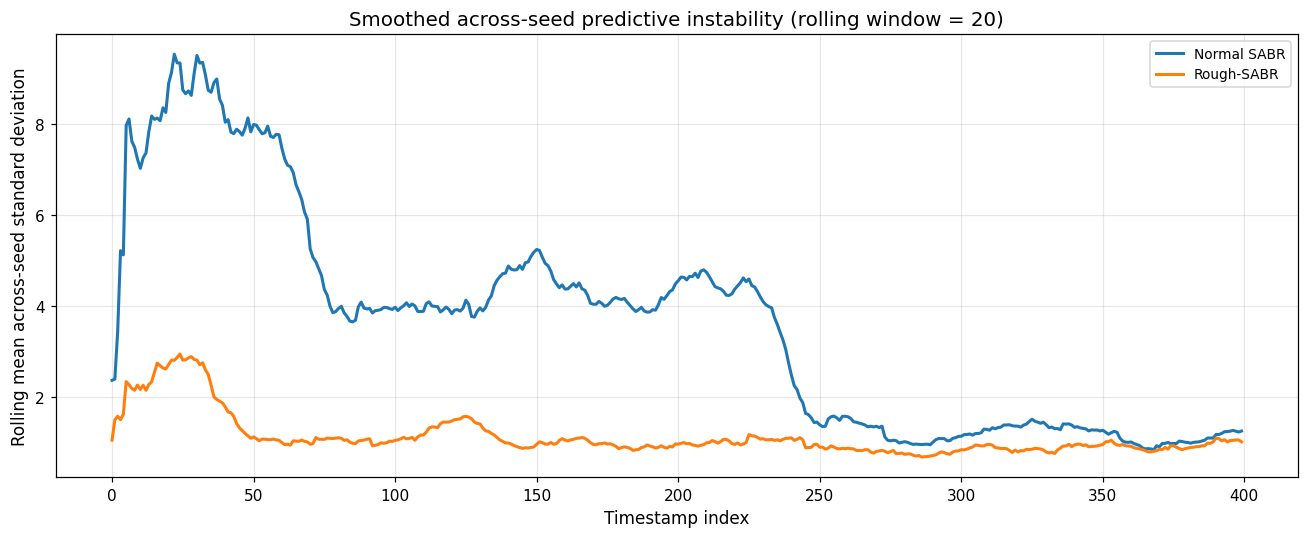

In [14]:
window = 20

normal_std_rolling = (
    across_seeds["normal_one_step_std"]
    .rolling(window=window, min_periods=1)
    .mean()
)

rough_std_rolling = (
    across_seeds["rough_one_step_std"]
    .rolling(window=window, min_periods=1)
    .mean()
)

fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    normal_std_rolling,
    linewidth=2,
    label="Normal SABR",
)

ax.plot(
    across_seeds["t_index"],
    rough_std_rolling,
    linewidth=2,
    label="Rough-SABR",
)

ax.set_title(
    f"Smoothed across-seed predictive instability "
    f"(rolling window = {window})"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Rolling mean across-seed standard deviation")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "predictive_ll_standard_deviation_rolling.png",
    bbox_inches="tight",
)
plt.show()

## 7. Cumulative predictive log-likelihood by seed

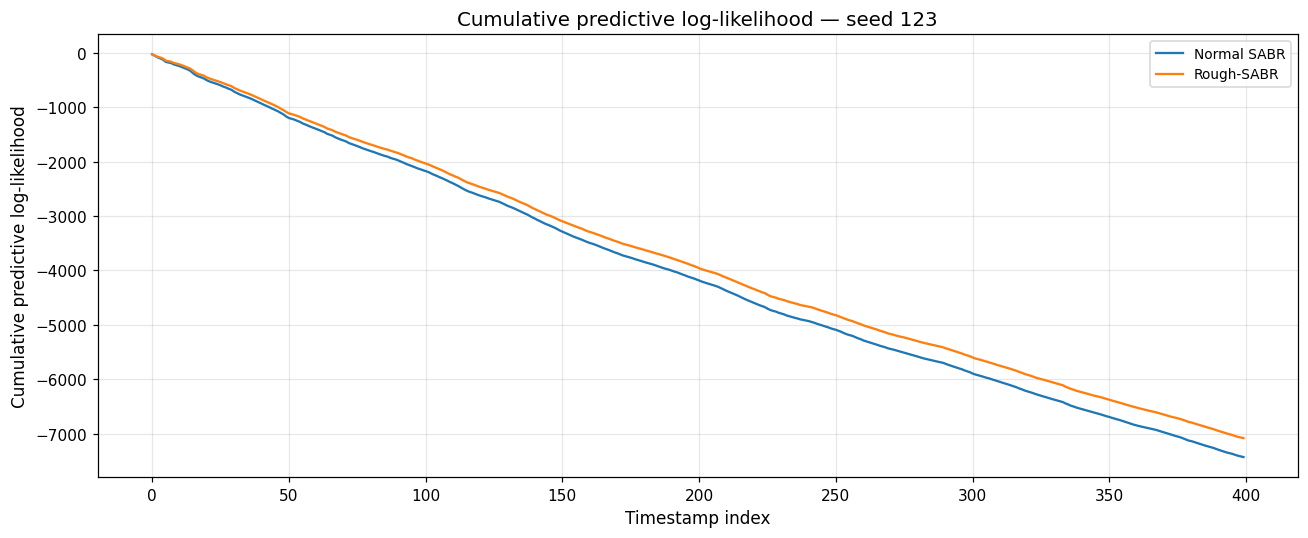

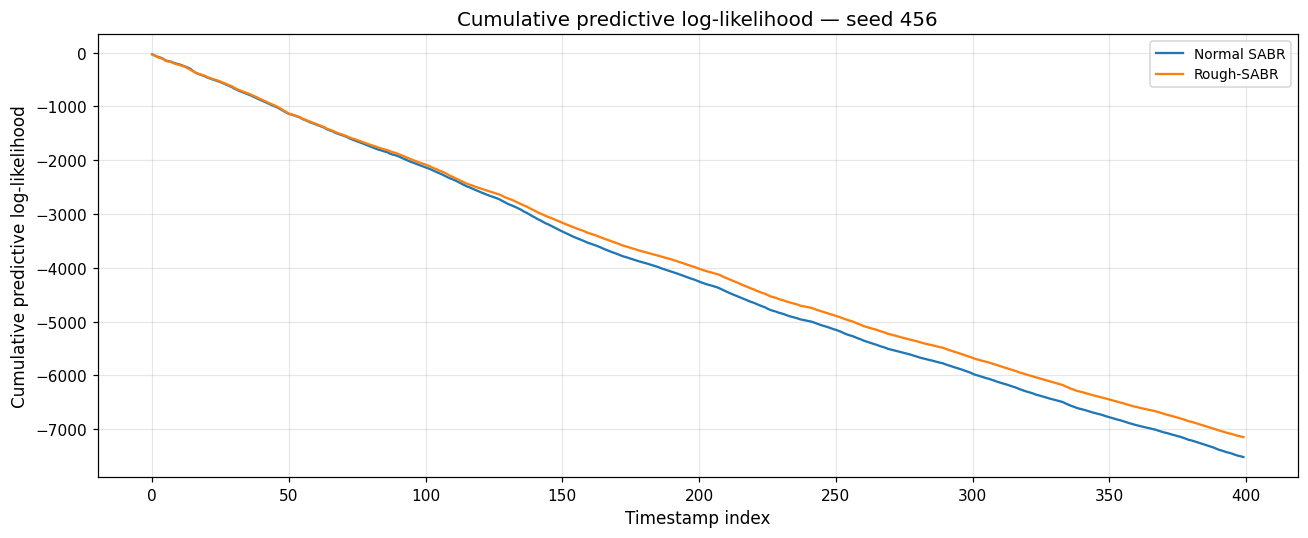

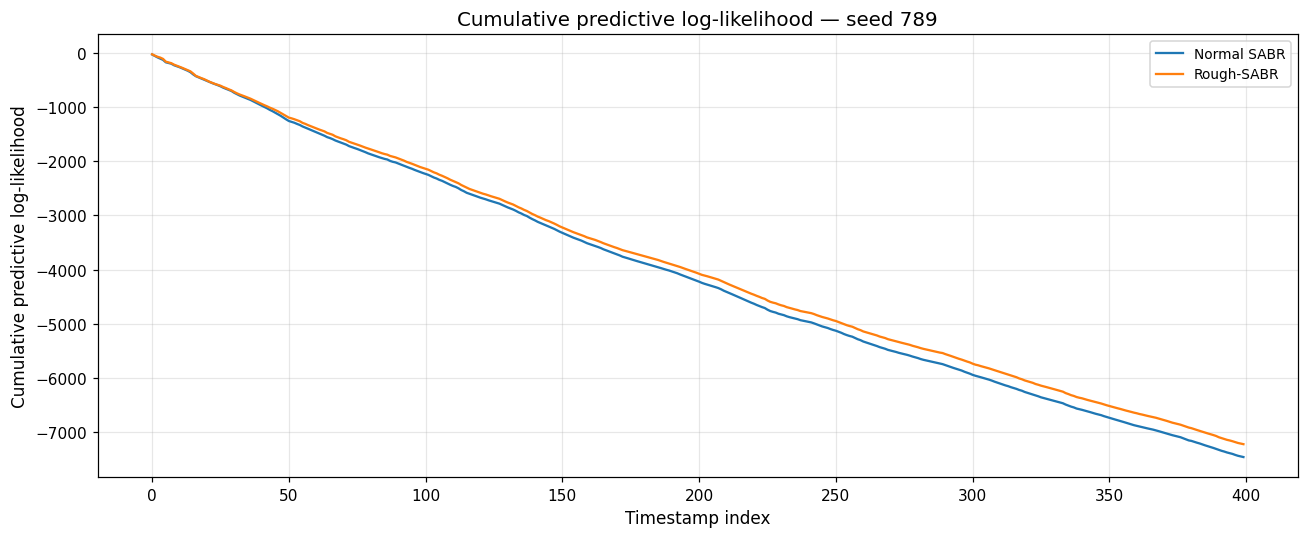

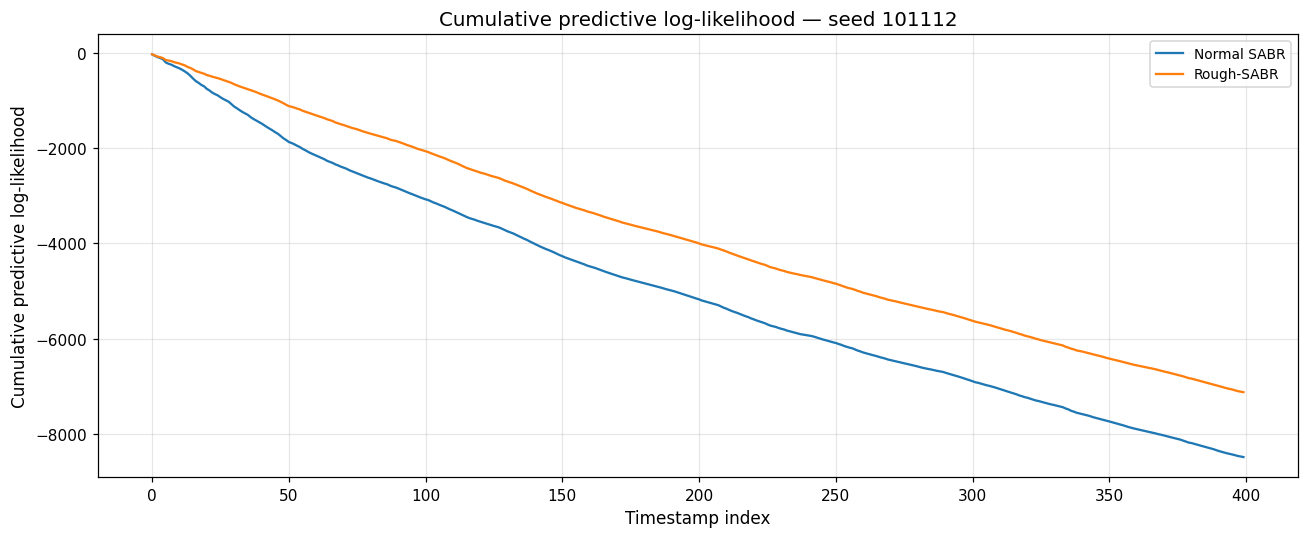

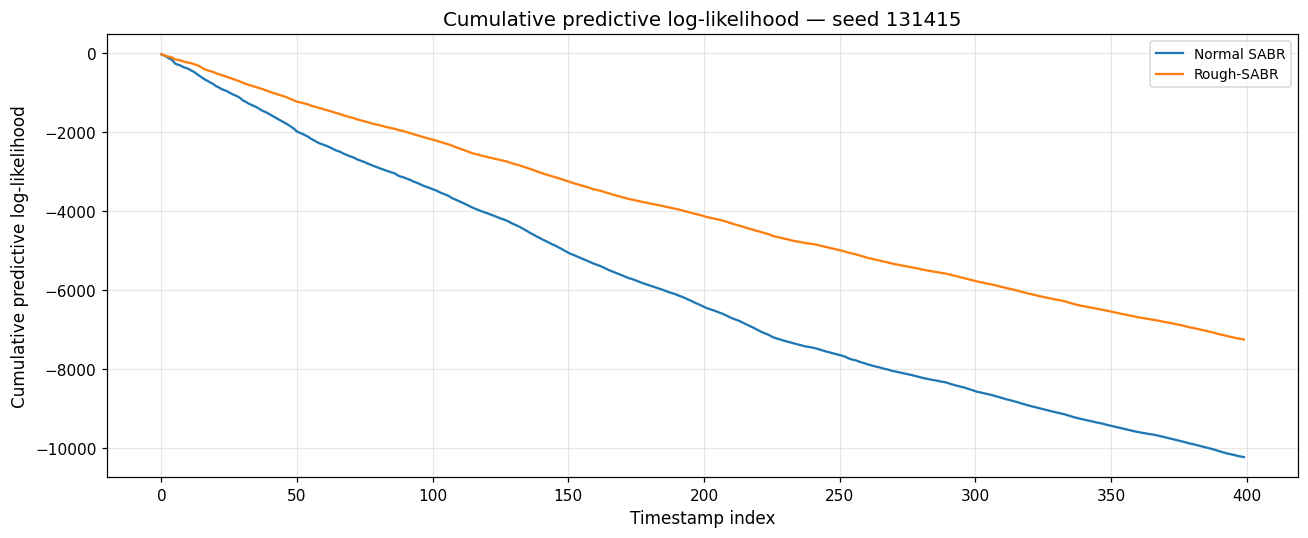

In [15]:
for seed, seed_data in paired.groupby("seed"):
    fig, ax = plt.subplots()

    ax.plot(
        seed_data["t_index"],
        seed_data["normal_cumulative_ll"],
        label="Normal SABR",
    )
    ax.plot(
        seed_data["t_index"],
        seed_data["rough_cumulative_ll"],
        label="Rough-SABR",
    )

    ax.set_title(
        f"Cumulative predictive log-likelihood — seed {seed}"
    )
    ax.set_xlabel("Timestamp index")
    ax.set_ylabel("Cumulative predictive log-likelihood")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"cumulative_predictive_ll_seed_{seed}.png",
        bbox_inches="tight",
    )
    plt.show()

## 8. Cumulative predictive log-likelihood across seeds

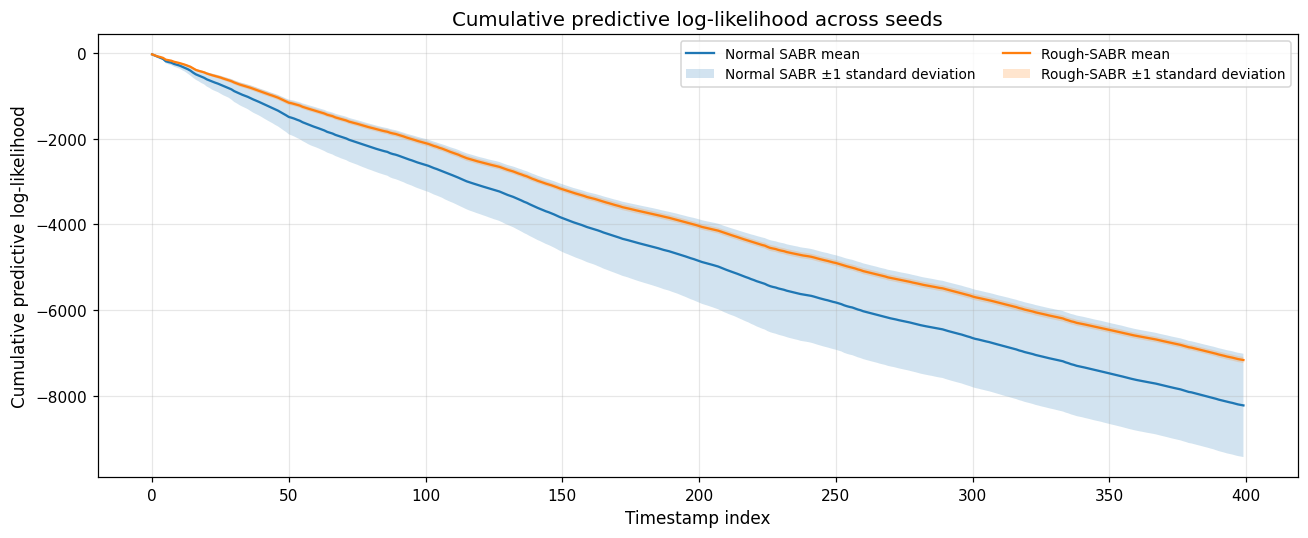

In [16]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["normal_cumulative_mean"],
    label="Normal SABR mean",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["normal_cumulative_mean"]
    - across_seeds["normal_cumulative_std"],
    across_seeds["normal_cumulative_mean"]
    + across_seeds["normal_cumulative_std"],
    alpha=0.2,
    label="Normal SABR ±1 standard deviation",
)

ax.plot(
    across_seeds["t_index"],
    across_seeds["rough_cumulative_mean"],
    label="Rough-SABR mean",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["rough_cumulative_mean"]
    - across_seeds["rough_cumulative_std"],
    across_seeds["rough_cumulative_mean"]
    + across_seeds["rough_cumulative_std"],
    alpha=0.2,
    label="Rough-SABR ±1 standard deviation",
)

ax.set_title("Cumulative predictive log-likelihood across seeds")
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Cumulative predictive log-likelihood")
ax.grid(alpha=0.3)
ax.legend(ncol=2)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "cumulative_predictive_ll_across_seeds.png",
    bbox_inches="tight",
)
plt.show()

## 9. Cumulative predictive log-likelihood difference by seed

The plotted quantity is

$$
D_{t,s}
=
C^{\mathrm{Rough}}_{t,s}
-
C^{\mathrm{Normal}}_{t,s}.
$$

Positive values favour Rough-SABR; negative values favour Normal SABR.

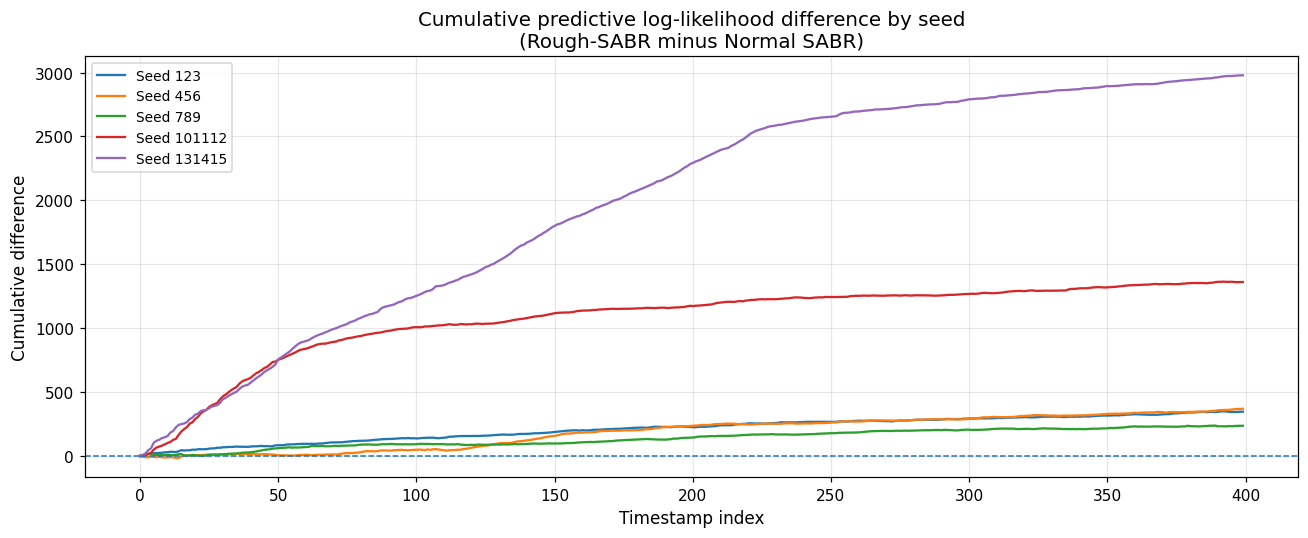

In [17]:
fig, ax = plt.subplots()

for seed, seed_data in paired.groupby("seed"):
    ax.plot(
        seed_data["t_index"],
        seed_data["cumulative_difference"],
        label=f"Seed {seed}",
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Cumulative predictive log-likelihood difference by seed\n"
    "(Rough-SABR minus Normal SABR)"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Cumulative difference")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "cumulative_predictive_ll_difference_by_seed.png",
    bbox_inches="tight",
)
plt.show()

## 10. Cumulative predictive log-likelihood difference across seeds

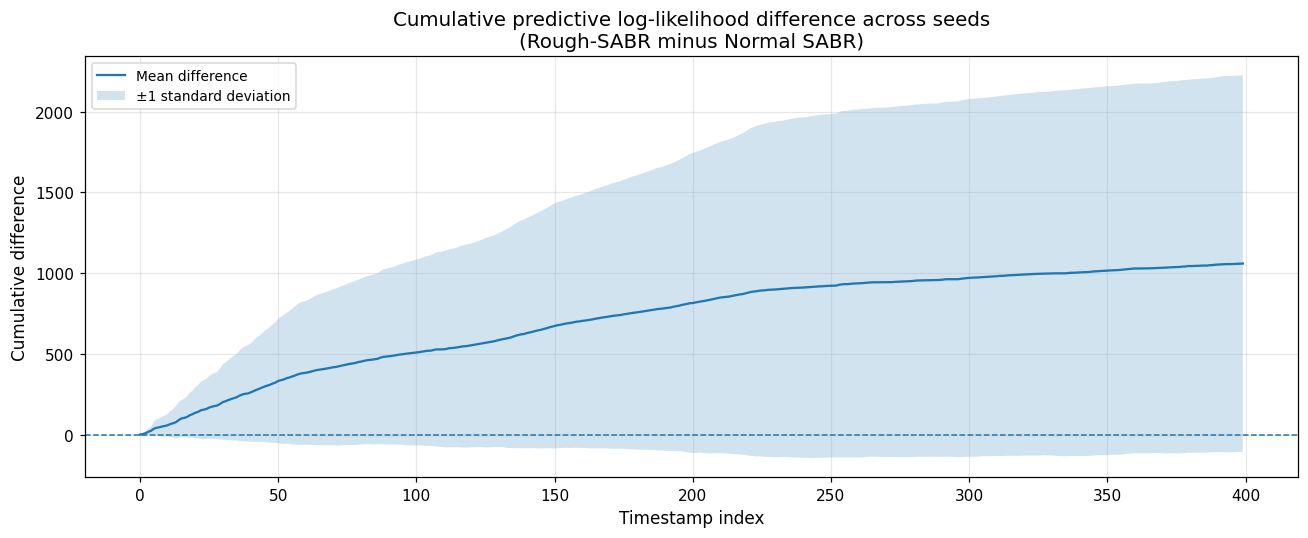

In [18]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["cumulative_difference_mean"],
    label="Mean difference",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["cumulative_difference_mean"]
    - across_seeds["cumulative_difference_std"],
    across_seeds["cumulative_difference_mean"]
    + across_seeds["cumulative_difference_std"],
    alpha=0.2,
    label="±1 standard deviation",
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Cumulative predictive log-likelihood difference across seeds\n"
    "(Rough-SABR minus Normal SABR)"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("Cumulative difference")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "cumulative_predictive_ll_difference_across_seeds.png",
    bbox_inches="tight",
)
plt.show()

## 11. One-step-ahead predictive log-likelihood difference by seed

The plotted quantity is

$$
\Delta_{t,s}
=
\ell^{\mathrm{Rough}}_{t,s}
-
\ell^{\mathrm{Normal}}_{t,s}.
$$

This figure shows whether the cumulative comparison is driven by persistent differences or by isolated timestamps.

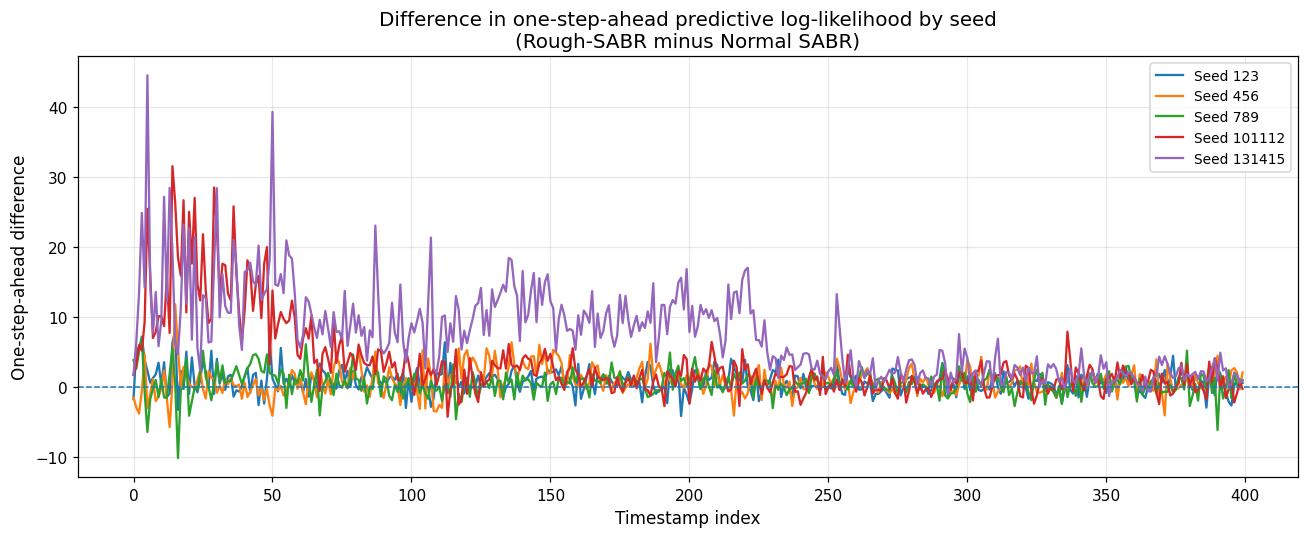

In [19]:
fig, ax = plt.subplots()

for seed, seed_data in paired.groupby("seed"):
    ax.plot(
        seed_data["t_index"],
        seed_data["one_step_difference"],
        label=f"Seed {seed}",
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Difference in one-step-ahead predictive log-likelihood by seed\n"
    "(Rough-SABR minus Normal SABR)"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("One-step-ahead difference")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "one_step_predictive_ll_difference_by_seed.png",
    bbox_inches="tight",
)
plt.show()

## 12. One-step-ahead predictive log-likelihood difference across seeds

The solid line shows the mean paired difference across seeds. The shaded region shows one standard deviation across seeds.

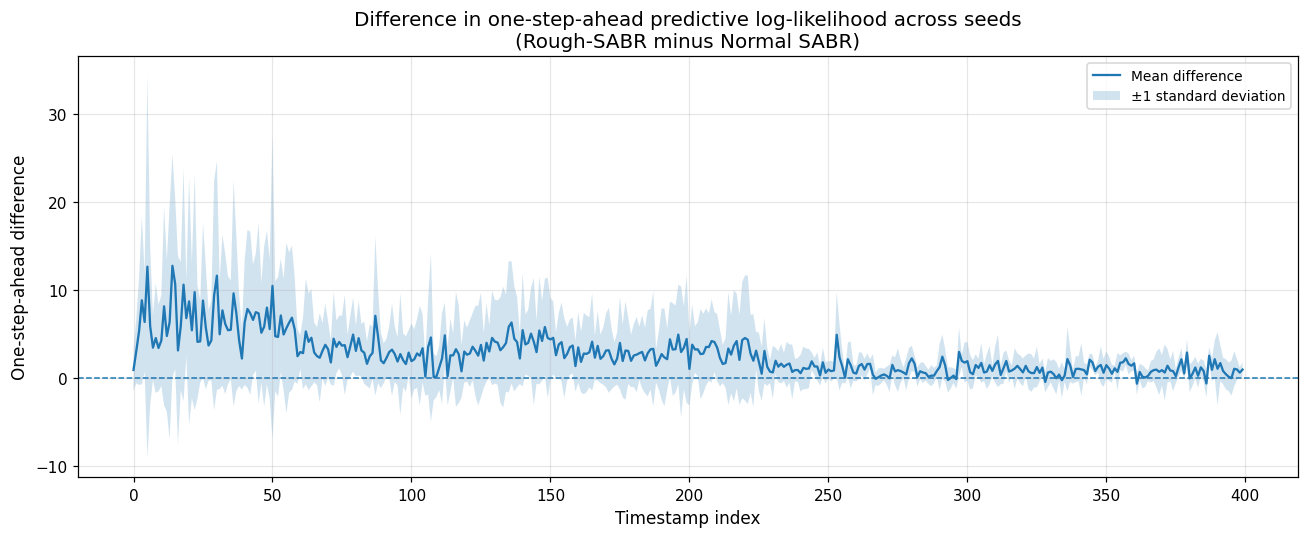

In [20]:
fig, ax = plt.subplots()

ax.plot(
    across_seeds["t_index"],
    across_seeds["one_step_difference_mean"],
    label="Mean difference",
)
ax.fill_between(
    across_seeds["t_index"],
    across_seeds["one_step_difference_mean"]
    - across_seeds["one_step_difference_std"],
    across_seeds["one_step_difference_mean"]
    + across_seeds["one_step_difference_std"],
    alpha=0.2,
    label="±1 standard deviation",
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title(
    "Difference in one-step-ahead predictive log-likelihood across seeds\n"
    "(Rough-SABR minus Normal SABR)"
)
ax.set_xlabel("Timestamp index")
ax.set_ylabel("One-step-ahead difference")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "one_step_predictive_ll_difference_across_seeds.png",
    bbox_inches="tight",
)
plt.show()